In [ ]:
import geopops
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import scipy.stats as stats
import networkx as nx
import starsim as ss
import sciris as sc

# 3.0 Explore Networks
In this notebook, we'll:
* 3.1 Calculate and compare statistics of each network (number of nodes and edges, mean degree)
* 3.2 Run a simulation and look at infections by network
* 3.3 Compare simulations when changing edge weight on a network
* 3.4 Compare simulations when changing mean degree on a network

## 3.1 Compare network statistics
`geopops.ForStarsim.GPNetwork()` takes the upper adjacency matrices for each network and stores them as edge lists, which can be turned into Starsim networks and passed into a simulation. In each edge list, a value in columns p1 or p2 corresponds to the agent uid in people_all.csv and the Starsim people object.

In [2]:
# Read in edge list dataframes
#  p1=person 1, p2=person 2, beta=edge weight
h_df = pd.read_csv("data/pop_export/starsim/net_h.csv").drop(columns=['Unnamed: 0'])
s_df = pd.read_csv("data/pop_export/starsim/net_s.csv").drop(columns=['Unnamed: 0'])
w_df = pd.read_csv("data/pop_export/starsim/net_w.csv").drop(columns=['Unnamed: 0'])
g_df = pd.read_csv("data/pop_export/starsim/net_g.csv").drop(columns=['Unnamed: 0'])
print('View home network edgelist')
w_df.head()

View home network edgelist


,p1,p2,beta
0,922,181,1
1,1699,1565,1
2,2033,218,1
3,2136,1038,1
4,2175,120,1


Now we'll calculate some basic network statistics in the cell below and print as a dataframe.

In [3]:
# Function to calculate network statistics
def get_stats_df(nets, names):
    rows = []
    stat_names = [
        "Mean degree",
        "Median degree",
        "Min degree",
        "Max degree",
        "Number of nodes",
        "Number of edges",
    ]

    for net, name in zip(nets, names):
        G = nx.from_pandas_edgelist(net, source="p1", target="p2", create_using=nx.Graph())
        degrees = np.array([d for _, d in G.degree()])
        values = [
            degrees.mean().round(2),
            np.median(degrees).round(2),
            degrees.min(),
            degrees.max(),
            G.number_of_nodes(),
            G.number_of_edges(),
        ]
        for stat, val in zip(stat_names, values):
            rows.append({"Network": name, "Statistic": stat, "GeoPops": val})

    df = pd.DataFrame(rows)
    return df.pivot(index="Statistic", columns="Network", values="GeoPops")

stats_df = get_stats_df(
    nets=[h_df, s_df, w_df, g_df],
    names=["Household", "School", "Workplace", "Group Quarters"],
)
stats_df

Network,Group Quarters,Household,School,Workplace
Statistic,,,,
Max degree,26.0,11.00,34.00,23.00
Mean degree,12.0,2.58,11.99,7.57
Median degree,12.0,2.00,12.00,8.00
Min degree,7.0,1.00,1.00,1.00
Number of edges,45174.0,333583.00,353092.00,490751.00
Number of nodes,7526.0,258268.00,58901.00,129715.00


Section 1.7.2 of `1_run_geopops.ipynb` explains how each network is generated. For example, the school and workplace networks are generated using stochastic block modeling with mean degrees of 12 and 8, respectively. You can adjust the parameters used in network generation with `WriteConfig()` before running `SynthPop()`. This would change the structure of your networks and, in turn, the progression of disease in the simulation. The following code illustrates the density of the home network by age (takes a while to run). You can see genrations of children, parents, and grandparents.


/var/folders/9n/1361ppx53h5cjy3q80rwhj540000gn/T/ipykernel_50898/3575014256.py:2: DtypeWarning: Columns (20) have mixed types. Specify dtype option on import or set low_memory=False.
  people = pd.read_csv(f'{path}/pop_export/people_all.csv')


<Axes: xlabel='p1_age', ylabel='p2_age'>

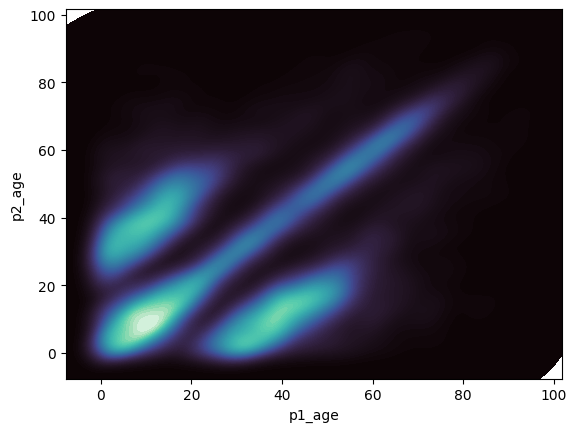

In [ ]:
people_all = pd.read_csv('data/pop_export/people_all.csv')
p1 = people_all[['uid','age']].rename(columns={'uid':'p1','age':'p1_age'})
p2 = people_all[['uid','age']].rename(columns={'uid':'p2','age':'p2_age'})

n = 'h' # swap this out with 's', 'w', or 'g' to see the other networks
net = pd.read_csv(f'data/pop_export/starsim/net_{n}.csv')
net = net.merge(p1,how='left',on='p1')
net = net.merge(p2,how='left',on='p2')

sns.kdeplot(
    data=net, x="p1_age", y="p2_age",
    fill=True, thresh=0, levels=100, cmap="mako",
)

The following cell counts how many agents there are in each network by age group. Just replace `n` with the network key: h=home, s=school, w=work, g=group quarters.

In [ ]:
people_all = pd.read_csv('data/pop_export/people_all.csv')
agegroup = people_all[['uid','agegroup']]
age = people_all[['uid','age']]

n = 's'
net = pd.read_csv('data/pop_export/starsim/net_{n}.csv')
p1 = net['p1']
p2 = net['p2']
net_uids = pd.concat([p1,p2])
net_uids = net_uids.drop_duplicates().reset_index().drop(columns=['index']).rename(columns={0:'uid'})
net_uids = net_uids.merge(agegroup, on='uid', how='left')
net_by_ag = net_uids.groupby('agegroup').size().reset_index().rename(columns={0:'count'})
net_by_ag

/var/folders/9n/1361ppx53h5cjy3q80rwhj540000gn/T/ipykernel_36731/3345782440.py:2: DtypeWarning: Columns (20) have mixed types. Specify dtype option on import or set low_memory=False.
  people_all = pd.read_csv(f'{path}/pop_export/people_all.csv')


,agegroup,count
0,0.0,21264
1,1.0,33736
2,2.0,453
3,3.0,602
4,4.0,555
5,5.0,484
6,6.0,282
7,7.0,52
8,8.0,10
9,9.0,6


## 3.2 Infections by network
Now we'll create a Starsim simulation and track outcomes by network. First, let's think about how Starsim decides who gets infected each time step. 

For each time step, Starsim knows who the infectious agents are (sources) and who the susceptible agents are (targets). For every contact (i.e., network edge) between agents, there is a probability of transmission every time step if one of those agents is infectious. To calculate that probability, starsim scales the base infectiousness of the disease by:
* The source’s relative transmissability (rel_sus) <-- will look at rel_sus and rel_trans in next notebook
* The target’s relative susceptibility (rel_trans)
* The effective transmission strength of that edge (i.e., edge_weight)

To decide if a target agent gets infected, Starsim draws a uniform random number between 0 and 1 for that contact.
If the probability is larger than the random draw, that contact is marked as having caused an infection. So, for each time step we have a list of infectious sources and a list of targets who got infected.

When an agent enters a state (e.g., I), Starsim samples and stores the future time that agent will transition out of that state (e.g., from dur_inf). When that stored time is reached, the agent transitions to the next state (e.g., R).

Now, load the people and define the networks.

In [ ]:
# load the people object
ppl = ss.load('data/pop_export/starsim/ppl.pkl')

# define the networks. This also rewrites the edge lists in pop_export/starsim/net_*.csv
h = geopops.ForStarsim.GPNetwork(name='homenet', edge_weight=1.0)
s = geopops.ForStarsim.GPNetwork(name='schoolnet', edge_weight=1.0)
w = geopops.ForStarsim.GPNetwork(name='worknet', edge_weight=1.0)
g = geopops.ForStarsim.GPNetwork(name='gqnet', edge_weight=1.0)

Network csv files created and saved successfully


The next cell modifies Starsim's pre-built SIR class so that we can track new infections by network. This will be passed into the sim later.

In [ ]:
# Adapted SIR class that tracks new infections by network
class SIRByNetwork(ss.SIR):
    """
    Same as Starsim's default SIR, but adds a result:
      - new_infections_by_network[t, net_idx]
    counting how many new infections occurred on each network at each timestep.
    """

    def __init__(self, pars=None, **kwargs):
        super().__init__(pars=pars, **kwargs)
        self.name = 'sir'  # stable module name for results (optional)

    def init_results(self):
        # Keep all default SIR/Infection results (n_infected, new_infections, etc.)
        super().init_results()

        n_steps = self.sim.t.npts
        n_nets = len(self.sim.networks)

        self.define_results(
            ss.Result(
                name='new_infections_by_network',
                module=self.name,
                dtype=int,
                shape=(n_steps, n_nets),   # time x network index
                scale=True,
                auto_plot=False,
                label='New infections by network',
            )
        )
        return

    def step(self):
        # Use the same infection mechanism as Infection.step(), but keep 'networks' output
        new_cases, sources, networks = self.infect()

        # Convert per-case network indices into counts per network
        n_nets = len(self.sim.networks)
        if len(new_cases):
            net_arrays = []
            for arr in networks:
                arr = np.atleast_1d(arr)
                if arr.size:
                    net_arrays.append(arr)
            if net_arrays:
                all_nets = np.concatenate(net_arrays)
                counts = np.bincount(all_nets, minlength=n_nets)
            else:
                counts = np.zeros(n_nets, dtype=int)
        else:
            counts = np.zeros(n_nets, dtype=int)

        self.results.new_infections_by_network[self.ti, :] = counts

        # Keep default behavior: set outcomes for new cases
        if len(new_cases):
            self.set_outcomes(new_cases, sources)

        return new_cases, sources, networks

Now define the Starsim sim object, run it, and plot infections by network.

Initializing sim with 357235 agents
  Running 0.0 ( 0/51) (0.00 s)  ———————————————————— 2%
  Running 10.0 (10/51) (1.54 s)  ••••———————————————— 22%
  Running 20.0 (20/51) (3.58 s)  ••••••••———————————— 41%
  Running 30.0 (30/51) (5.97 s)  ••••••••••••———————— 61%
  Running 40.0 (40/51) (8.20 s)  ••••••••••••••••———— 80%
  Running 50.0 (50/51) (10.00 s)  •••••••••••••••••••• 100%



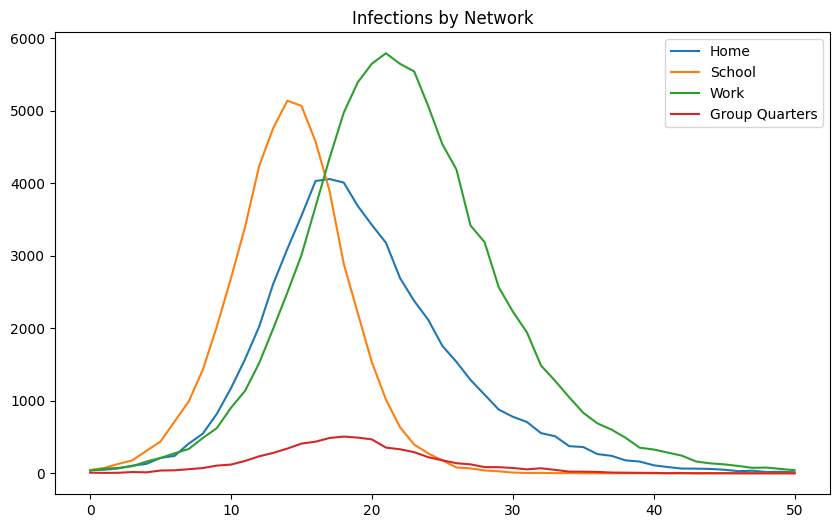

In [ ]:
# Define your SIR disease model and parameters
sir_adapted = SIRByNetwork(sc.objdict(init_prev=ss.bernoulli(p=0.001), # Initial prevalence, drawn from Bernoulli distribution
                                      beta=0.05, # Disease's base infectiousness 
                                                 # scaled by rel_trans, rel_sus, and edge_weight <--will see these later
                                      dur_inf=ss.normal(7.0), # Duration of infectiousness, drawn from normal distribution
                                      p_death=ss.bernoulli(p=0.001) # Probability of death, drawn from Bernoulli distribution
                                      ))
                        
# Run the model
np.random.seed(123)
sim1 = ss.Sim(
    pars    = sc.objdict(start = 0, stop  = 50, dt = 1.0),
    people  = ppl, # people object
    networks = [h,s,w,g], # networks
    diseases = [sir_adapted],  # disease model
).run()

#Store the results
res1 = sim1.results

# Function for plotting new infections by network
def plot_infections_by_network(res):
    infs_h = res['sir'].new_infections_by_network[:, 0]
    infs_s = res['sir'].new_infections_by_network[:, 1]
    infs_w = res['sir'].new_infections_by_network[:, 2]
    infs_g = res['sir'].new_infections_by_network[:, 3]

    plt.figure(figsize=(10, 6))
    plt.title('Infections by Network')
    plt.plot(res.timevec, infs_h, label='Home')
    plt.plot(res.timevec, infs_s, label='School')
    plt.plot(res.timevec, infs_w, label='Work')
    plt.plot(res.timevec, infs_g, label='Group Quarters')
    plt.legend()
    plt.show()

# Plot infections by network
plot_infections_by_network(res1)

Now try redefining your edge weights in the networks and see how it affects the simulation in the cell below.

Initializing sim with 357235 agents
  Running 0.0 ( 0/51) (0.00 s)  ———————————————————— 2%
  Running 10.0 (10/51) (1.54 s)  ••••———————————————— 22%
  Running 20.0 (20/51) (3.59 s)  ••••••••———————————— 41%
  Running 30.0 (30/51) (5.57 s)  ••••••••••••———————— 61%
  Running 40.0 (40/51) (7.71 s)  ••••••••••••••••———— 80%
  Running 50.0 (50/51) (9.53 s)  •••••••••••••••••••• 100%



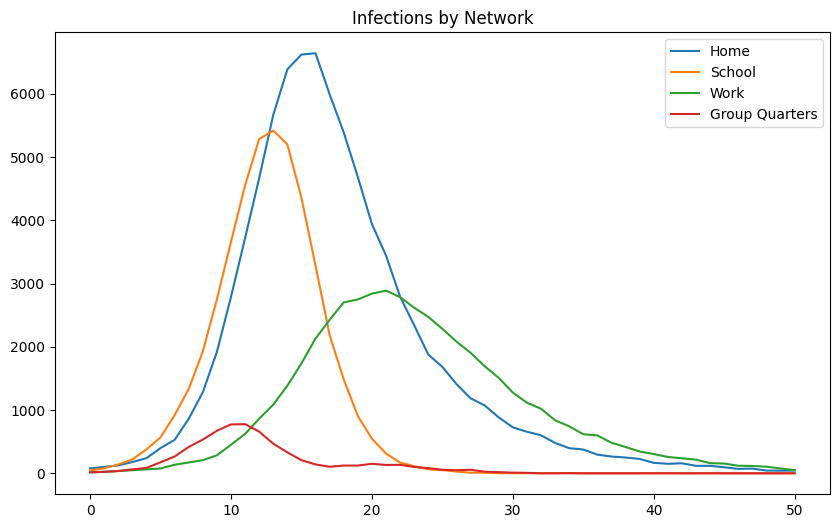

In [ ]:
# Redefine the networks with new edge weights
h2 = geopops.ForStarsim.GPNetwork(name='homenet', edge_weight=2.0)
s2 = geopops.ForStarsim.GPNetwork(name='schoolnet', edge_weight=1.0)
w2 = geopops.ForStarsim.GPNetwork(name='worknet', edge_weight=0.5)
g2 = geopops.ForStarsim.GPNetwork(name='gqnet', edge_weight=2.0)

# Run the model
sim2 = ss.Sim(
    pars    = sc.objdict(start = 0, stop  = 50, dt = 1.0),
    people  = ppl,
    networks = [h2,s2,w2,g2],
    diseases = [sir_adapted],  # use custom Measles model
).run()

#Store the results
res2 = sim2.results

# Plot infections by network
plot_infections_by_network(res2)